# LAB 2
En este lab repasaremos los conceptos vistos en la clase 3 Estimadores no gaussianos


## Bibliotecas a importar

* yfinance: la usaremos para descargar información
* numpy: la usaremos para realizar diversas operaciones matemáticas
* pandas: la usaremos para realizar cálculos con vectores
* analisis_portafolios: nuestra biblioteca del curso que tendrá funciones para los procedimientos vistos en clase
* scipy.stats: la usaremos para calcular sesgo, curtosis y prueba Jarque-Bera

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import analisis_portafolios as ap
import scipy.stats as stats

## Descargamos la información a analizar

In [3]:
ticker = "AAPL" # ticker de la acción a analizar
fecha_inicio = "2025-01-01" # fecha de inicio para descargar
fecha_fin = "2025-12-31" # fecha final para descargar

In [4]:
datos = yf.download(ticker, start=fecha_inicio, end=fecha_fin)

[*********************100%***********************]  1 of 1 completed


In [5]:
# visualizamos informacion descargada
datos.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-01-02,242.093140,247.305315,240.077766,247.136526,55740700
2025-01-03,241.606644,242.420728,240.147234,241.606644,40244100
2025-01-06,243.234833,245.548047,241.447798,242.549802,45045600
2025-01-07,240.464935,243.780868,239.611131,241.229377,40856000
2025-01-08,240.951401,241.954134,238.320499,240.177022,37628900


In [6]:
# extraemos la columna que nos interesa analizar
precio_cierre = datos[("Close", "AAPL")]

In [7]:
# calculamos rendimiento simple y eliminamos NA's
rend_simple = precio_cierre.pct_change().dropna()

## Reglas empíricas de asimetría (Media vs. Mediana)

* **$\text{Media} > \text{Mediana}$ $\rightarrow$ Sesgo positivo (cola a la derecha):**
* **$\text{Media} < \text{Mediana}$ $\rightarrow$ Sesgo negativo (cola a la izquierda):**
* **$\text{Media} \approx \text{Mediana}$ $\rightarrow$ Distribución aproximadamente simétrica:**

> ⚠️ **Nota:** Esta heurística aplica principalmente a distribuciones **unimodales y continuas**. En distribuciones multimodales o discretas con colas pesadas, la regla puede no cumplirse.

In [8]:
rend_simple.describe()

count    248.000000
mean       0.000681
std        0.020489
min       -0.092456
25%       -0.006729
50%        0.000790
75%        0.006617
max        0.153289
Name: (Close, AAPL), dtype: float64

Dado que media < mediana esperamos una distribución con sesgo negativo (cola izquierda)

## Histograma
Antes de calcular el sesgo y curtosis podemos hacer un análisis visual del histograma de nuestro rendimientos para tener una primer idea de lo que podemos esperar al realizar los cálculos

<Axes: >

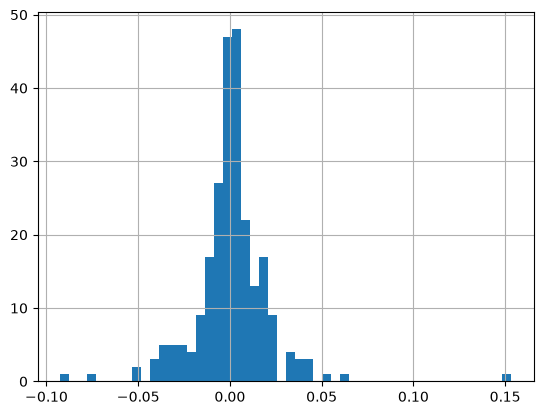

In [9]:
rend_simple.hist(bins=50)

## Sesgo

In [10]:
# Calculamos el sesgo (muestral)
# Dado que estamos utilizando una muestra utilizamos "bias=False"
sesgo_muestral = stats.skew(rend_simple, bias=False)
print(f"Sesgo muestral: {sesgo_muestral}")

Sesgo muestral: 1.1289779731366245


El sesgo no es negativo como esperabamos al comparar media con mediana, esto probablemente se deba a colas pesadas (exceso de curtosis)

## Curtosis

El resultado de la siguiente función se compara con 0 ya que nos otorga el **exceso de curtosis**

In [11]:
# Curtosis muestral
curtosis_muestral = stats.kurtosis(rend_simple, bias=False)
print(f"Curtosis muestral: {curtosis_muestral}")

Curtosis muestral: 14.153535453911246


Confirmamos nuestras sospechas, la distribución tiene curtosis alta, por eso la regla empírica de media con mediana no se cumplió

## Prueba Jarque-Bera

In [12]:
ap.prueba_jarque_bera(rend_simple, 0.05)

Estadístico: 2032.980
P-value: 0.0
Con un nivel de significancia del 5.0% se rechaza la hipótesis nula
Los rendimientos no tienen el sesgo y curtosis de una distribución normal


(np.float64(2032.9795401626857), np.float64(0.0))

Recordar cómo funciona una **prueba de hipótesis** (inferencia estadística):

Si suponemos que la hipótesis nula se cumple, **¿cuál es la probabilidad de que suceda la observación actual?**

*   Si dicha probabilidad es menor a nuestro nivel de significancia "**α**" entonces "*con un nivel de significancia del 100α% se rechaza la hipótesis nula*"
*   En caso de que "**p**" sea mayor a "**α**" eso no significa que se acepte la hipótesis nula, simplemente "*con un nivel de significancia del 100α% no hay evidencia suficiente para rechazarla*". >> ES INOCENTE HASTA QUE SE DEMUESTRE LO CONTRARIO

## Análisis con rendimientos logaritmicos
Sólo por curiosidad calculemos los estimadores anteriores para los rendimientos logaritmicos. Pues comentamos en las diapositivas que es más probable que ellos presenten una distribución normal.

In [13]:
rend_log = np.log(precio_cierre / precio_cierre.shift(1)).dropna()

<Axes: >

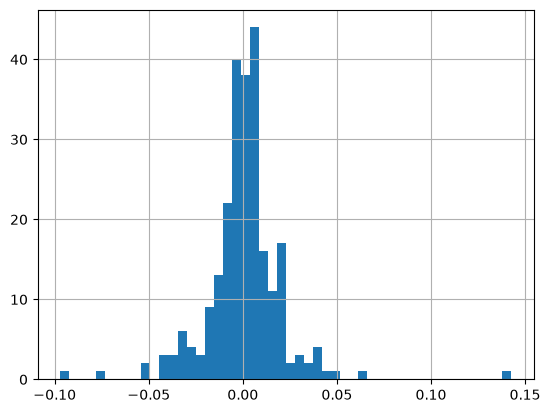

In [14]:
rend_log.hist(bins=50)

In [15]:
stats.skew(rend_log, bias=False)

np.float64(0.7083717483850492)

In [16]:
stats.kurtosis(rend_log, bias=False)

np.float64(11.980923523611098)

In [17]:
ap.prueba_jarque_bera(rend_log, 0.05)

Estadístico: 1439.046
P-value: 0.0
Con un nivel de significancia del 5.0% se rechaza la hipótesis nula
Los rendimientos no tienen el sesgo y curtosis de una distribución normal


(np.float64(1439.04555097954), np.float64(0.0))

## Uso manual de funciones
Si queremos usar las funciones vistas anteriormente con datos que queramos capturar manualmente el formato será el siguiente:

In [18]:
# Supongamos que estos son tus rendimientos
rend = pd.Series([0.01, -0.005, 0.007, -0.002, 0.003, 0.02, -0.015, 0.004])

In [19]:
stats.skew(rend, bias=False)

np.float64(-0.0949414765638426)

## Semivolatilidad

In [ ]:
# si no ponemos un valor objetivo elegirá la media
ap.semideviation(rend_simple) 

np.float64(0.019716409920982905)

In [31]:
# igual podemos estar interesados en cómo se comporta debajo del cero
ap.semideviation(rend_simple, objetivo=0) 

np.float64(0.019683028775466262)

In [22]:
# Los resultados son similares porque la media es casi 0
rend_simple.mean()

np.float64(0.0006811895251997946)

## VaR "Value at Risk"

### VaR Histórico

In [ ]:
#Devuelve el VaR histórico 95%
ap.var_historic(rend_simple, level=5) 

np.float64(0.03213921877549281)

Probemos con el ejemplo visto en la diapositiva en clase.

EJEMPLO. Calcular el VaR histórico al 90% de los siguientes rendimientos
* 0.015, 0.023, -0.016, -0.021, 0.007, 0.017, -0.019, 0.016, -0.035, 0.045

In [24]:
rend_ejemplo = pd.Series([0.015, 0.023, -0.016, -0.021, 0.007, 0.017, -0.019, 0.016, -0.035, 0.045])

In [26]:
ap.var_historic(rend_ejemplo, level=10)

np.float64(0.0224)

El resultado anterior es diferente al obtenido en clase porque la función realiza una interpolación. Si queremos elija el percentil "empírico" tenemos que especificar el argumento "lower" en el parámetro "method", como se muestra a continuación:

In [ ]:
-np.percentile(rend_ejemplo, 10, method="lower")

np.float64(0.035)

### Var Gaussiano
La siguiente función nos servirá para
* VaR Gaussiano
* VaR Semi-paramétrico (Cornish-Fisher)

In [ ]:
# VaR Gaussiano 95% (predeterminado)
ap.var_gaussiano(rend_simple)

np.float64(0.03302056027047421)

In [ ]:
# VaR Cornish-Fisher 95%
ap.var_gaussiano(rend_simple, modified=True) 

np.float64(0.02010233190551744)

## CVaR "Conditional Value at Risk"

In [ ]:
# CVaR al 95%, es el valor promedio en el peor 5% de nuestros datos
ap.cvar_historic(rend_simple) 

np.float64(0.04567277377805945)